# Correlation Funnel – Python Port

This notebook demonstrates the three-step EDA workflow ported from the R  
`correlationfunnel` package by Business Science.

**Workflow**

```
raw DataFrame
    -> binarize()               # convert numeric/categorical to binary (0/1)
    -> correlate(target)        # Pearson r of every binary feature vs target
    -> plot_correlation_funnel()  # tornado chart: strongest predictors at top
```

**Dataset**: Bank Marketing (UCI ML Repository).  
Target: did the client subscribe to a **term deposit**? (`TERM_DEPOSIT` = yes/no)

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from funnel_correlation_py import binarize, correlate, plot_correlation_funnel
from funnel_correlation_py.data import load_marketing_campaign

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load data

In [2]:
df = load_marketing_campaign()

# Drop ID column — not predictive
df = df.drop(columns=['ID'])

print(f'Shape: {df.shape}')
df.head()

Shape: (4521, 17)


,AGE,JOB,MARITAL,EDUCATION,DEFAULT,BALANCE,HOUSING,LOAN,CONTACT,DAY,MONTH,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,TERM_DEPOSIT
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
df.dtypes

AGE              int64
JOB             object
MARITAL         object
EDUCATION       object
DEFAULT         object
BALANCE          int64
HOUSING         object
LOAN            object
CONTACT         object
DAY              int64
MONTH           object
DURATION         int64
CAMPAIGN         int64
PDAYS            int64
PREVIOUS         int64
POUTCOME        object
TERM_DEPOSIT    object
dtype: object

In [4]:
# Target distribution
df['TERM_DEPOSIT'].value_counts(normalize=True).round(3)

TERM_DEPOSIT
no     0.885
yes    0.115
Name: proportion, dtype: float64

## 2. Binarize

### What happens under the hood

| Column type | Transformation |
|-------------|----------------|
| Numeric (continuous) | Quantile binning into `n_bins` ranges, then one-hot encoded |
| Categorical (string/category) | Rare levels lumped into `-OTHER`, then one-hot encoded |
| Boolean | Cast to `int` first, then treated as numeric |
| Constant columns | Dropped (zero variance) |

In [5]:
binary_df = binarize(
    df,
    n_bins=4,          # 4 quantile bins for numeric columns
    thresh_infreq=0.01,  # lump levels with <1% frequency
    name_infreq='-OTHER',
    one_hot=True,
)

print(f'Original shape : {df.shape}')
print(f'Binarized shape: {binary_df.shape}')
binary_df.head()

Original shape : (4521, 17)
Binarized shape: (4521, 74)


,AGE__19_33,AGE__33_39,AGE__39_49,AGE__49_87,BALANCE__-3313_69,BALANCE__1480_71188,BALANCE__444_1480,BALANCE__69_444,DAY__16_21,DAY__1_9,...,PREVIOUS__2,PREVIOUS__3,PREVIOUS__4,PREVIOUS__5,POUTCOME__failure,POUTCOME__other,POUTCOME__success,POUTCOME__unknown,TERM_DEPOSIT__no,TERM_DEPOSIT__yes
0,1,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,1,0
1,1,0,0,0,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,1,0
2,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,1,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,1,0
4,0,0,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,1,0


In [6]:
# Verify all values are 0 or 1
assert set(binary_df.values.flatten()).issubset({0, 1}), 'Non-binary values found!'
print('All values confirmed 0 or 1.')

All values confirmed 0 or 1.


## 3. Correlate

Computes Pearson r between every binary feature and the target.  
Result is sorted by |r| descending so the strongest predictors are at the top.

In [7]:
# Inspect which columns represent our target
[c for c in binary_df.columns if 'TERM_DEPOSIT' in c]

['TERM_DEPOSIT__no', 'TERM_DEPOSIT__yes']

In [8]:
corr_df = correlate(binary_df, target='TERM_DEPOSIT__yes')

print(f'Correlation table shape: {corr_df.shape}')
corr_df.head(15)

Correlation table shape: (73, 3)


,feature,bin,correlation
0,TERM_DEPOSIT,no,-1.000000
1,DURATION,329_3025,0.329218
2,POUTCOME,success,0.283481
3,DURATION,4_104,-0.180720
4,PREVIOUS,0,-0.162038
5,PDAYS,-1,-0.162038
6,PDAYS,-OTHER,0.162038
7,POUTCOME,unknown,-0.162038
8,MONTH,oct,0.145964
9,CONTACT,unknown,-0.139399


## 4. Plot – static (matplotlib)

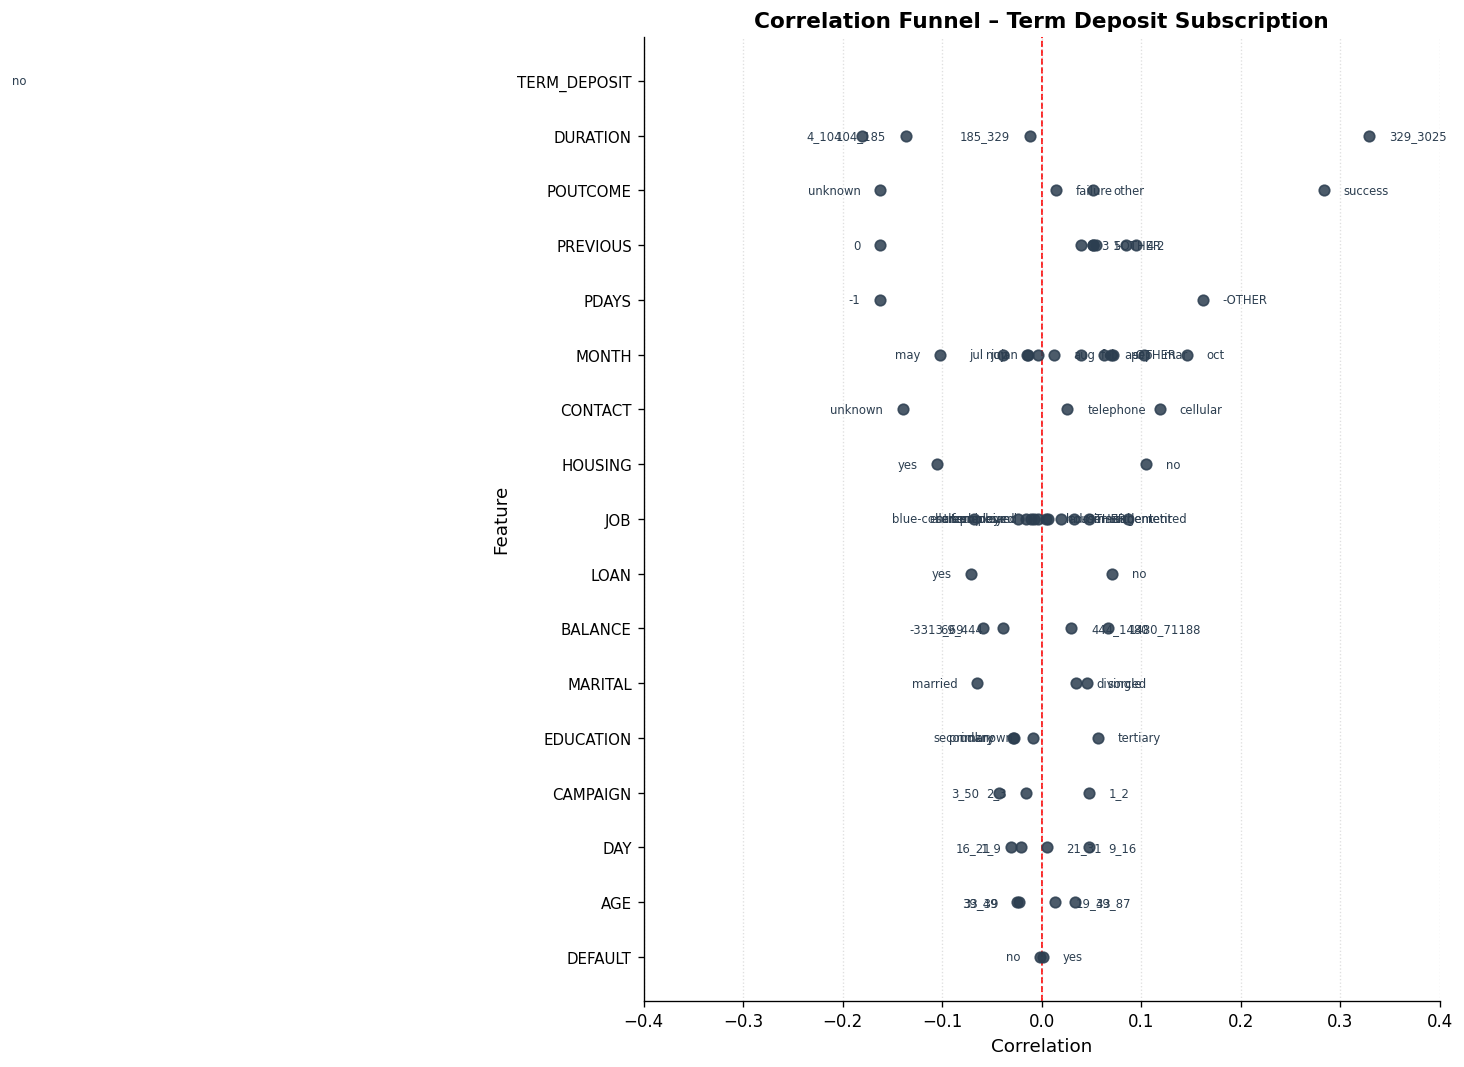

In [9]:
fig = plot_correlation_funnel(
    corr_df,
    interactive=False,
    limits=(-0.4, 0.4),
    alpha=0.85,
    figsize=(10, 9),
    title='Correlation Funnel – Term Deposit Subscription',
)
plt.tight_layout()
plt.show()

## 5. Plot – interactive (plotly)

Hover over any point to see `feature | bin | r` details.

In [10]:
fig_interactive = plot_correlation_funnel(
    corr_df,
    interactive=True,
    limits=(-0.4, 0.4),
    title='Correlation Funnel – Term Deposit (interactive)',
)
fig_interactive.show()

## 6. Interpret the results

The funnel shows features sorted from **most** to **least** correlated (top to bottom).  
Points to the **right** of zero are positively correlated with subscribing.  
Points to the **left** are negatively correlated.

Key takeaways from the marketing_campaign dataset:  
- `DURATION` (call duration in seconds) is typically the strongest predictor.
  Long calls tend to convert.  
- `POUTCOME__success` (previous campaign succeeded) is strongly positive.  
- `PDAYS` (days since last contact): not contacted recently is negative.  
- `JOB` and `EDUCATION` show moderate signal.

## 7. Customer Churn example

Same three-step pipeline, different dataset.

In [11]:
from funnel_correlation_py.data import load_customer_churn

churn_df = load_customer_churn()
print(churn_df.shape)
churn_df.head(3)

(7043, 21)


,CUSTOMERID,GENDER,SENIORCITIZEN,PARTNER,DEPENDENTS,TENURE,PHONESERVICE,MULTIPLELINES,INTERNETSERVICE,ONLINESECURITY,...,DEVICEPROTECTION,TECHSUPPORT,STREAMINGTV,STREAMINGMOVIES,CONTRACT,PAPERLESSBILLING,PAYMENTMETHOD,MONTHLYCHARGES,TOTALCHARGES,CHURN
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [12]:
# Drop non-predictive ID column if present
drop_cols = [c for c in ['CUSTOMERID', 'ID'] if c in churn_df.columns]
churn_df = churn_df.drop(columns=drop_cols)

# Convert TOTALCHARGES to numeric (may be string in raw UCI data)
if churn_df['TOTALCHARGES'].dtype == object:
    churn_df['TOTALCHARGES'] = pd.to_numeric(churn_df['TOTALCHARGES'], errors='coerce')
    churn_df = churn_df.dropna(subset=['TOTALCHARGES'])

churn_binary  = binarize(churn_df)
churn_target  = [c for c in churn_binary.columns if 'CHURN__Yes' in c or 'CHURN__YES' in c]
print('Target column candidates:', churn_target)

Target column candidates: ['CHURN__Yes']


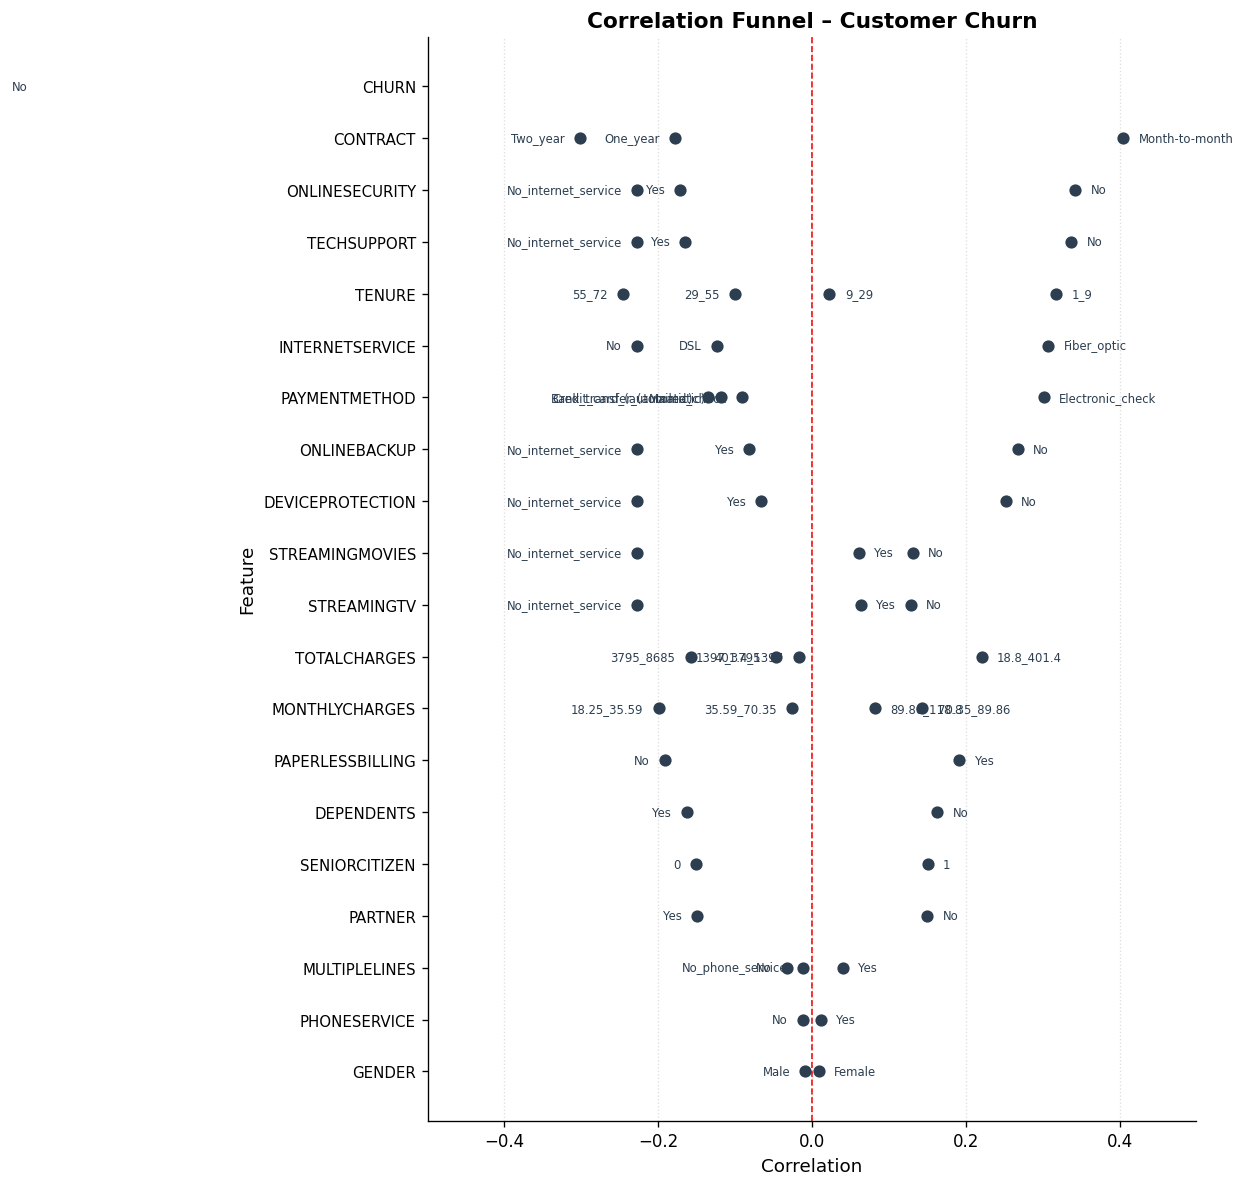

In [13]:
target_col = churn_target[0] if churn_target else None

if target_col:
    churn_corr = correlate(churn_binary, target=target_col)
    fig_churn  = plot_correlation_funnel(
        churn_corr,
        interactive=False,
        limits=(-0.5, 0.5),
        figsize=(10, 10),
        title='Correlation Funnel – Customer Churn',
    )
    plt.tight_layout()
    plt.show()
else:
    print('Could not identify CHURN target column — check column names above.')